## Dataset

### Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import glob
import geopandas as gpd
from shapely import wkt

manhattan = np.array([127, 128, 153, 120, 243, 244, 116, 42, 152, 166, 41, 74, 194, 24, 151,
                      238, 75, 239, 43, 236, 263, 143, 142, 262, 50, 237, 141, 140, 202, 163,
                      48, 230, 161, 162, 229, 246, 100, 68, 186, 233, 164, 170, 90, 234, 137,
                      158, 249, 107, 113, 224, 114, 125, 79, 211, 4, 144, 231, 148, 232, 13,
                      261, 45, 209, 87, 12, 88]) # 105, 104, 103

nyc = gpd.read_file('../NYC_zones/taxi_zones.shp')
manh = nyc.loc[nyc['LocationID'].isin(manhattan)]

df = pd.read_csv('data24.csv') # sample file name

stations_gdf = gpd.GeoDataFrame(geometry=df['Georeference'].apply(wkt.loads), crs="EPSG:4326")
polygons_series = manh['geometry'].to_crs("EPSG:4326")
polygons_gdf = gpd.GeoDataFrame(geometry=polygons_series, crs=polygons_series.crs)

matched = gpd.sjoin(
    stations_gdf,
    polygons_gdf,
    how = 'left',  # Keep all stations even if no match
    predicate = 'within'
)

df['PULocationID'] = matched['index_right']
df['pickup_datetime'] = pd.to_datetime(df['transit_timestamp'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 5.5))

points = gpd.GeoSeries(stations_gdf['geometry'].unique())
polygons_gdf.plot(ax = ax, color='white', edgecolor='black', linewidth = 0.3, alpha = 0.5)
points.plot(ax = ax, color='red', edgecolor='purple', alpha = 0.5, markersize = 35)
ax.set_axis_off()
# fig.savefig('Manhattan_subway_station.png', bbox_inches = 'tight')

In [ ]:
data = pd.DataFrame()
data['pickup_datetime'] = df['pickup_datetime']
data['PULocationID'] = df['PULocationID']
data['ridership'] = pd.to_numeric(df['ridership'], errors='coerce').fillna(0)

data['month'] =  data['pickup_datetime'].dt.month
data['day'] = data['pickup_datetime'].dt.day
data['hour'] = data['pickup_datetime'].dt.hour

data = data.groupby(['PULocationID', 'month', 'day', 'hour'])['ridership'].sum().reset_index(name = 'count')

n = len(data)
a = np.zeros(n)
for i in range(n):
    a[i] = 24 * (data['day'][i] - 1) + data['hour'][i]
data['time_step'] = a

sample = data[data['month'] == 1].reset_index(drop=True, inplace=False)
t = 24 * sample['day'].max()
mat = np.zeros((263, t))
for i in range(len(sample)):
    mat[int(sample['PULocationID'][i]), int(sample['time_step'][i])] = sample['count'][i]
for month in range(1, 12):
    sample = data[data['month'] == month + 1].reset_index(drop=True, inplace=False)
    t = 24 * sample['day'].max()
    mat_new = np.zeros((263, t))
    for i in range(len(sample)):
        mat_new[int(sample['PULocationID'][i]), int(sample['time_step'][i])] = sample['count'][i]
    mat = np.append(mat, mat_new, axis = 1)

# np.savez_compressed('NYC_subway_mob_24.npz', mat)

### Visualization

In [1]:
import numpy as np

manhattan = np.array([127, 128, 153, 120, 243, 244, 116, 42, 152, 166, 41, 74, 194, 24, 151,
                      238, 75, 239, 43, 236, 263, 143, 142, 262, 50, 237, 141, 140, 202, 163,
                      48, 230, 161, 162, 229, 246, 100, 68, 186, 233, 164, 170, 90, 234, 137,
                      158, 249, 107, 113, 224, 114, 125, 79, 211, 4, 144, 231, 148, 232, 13,
                      261, 45, 209, 87, 12, 88]) # 105, 104, 103

mat = np.load('NYC_subway_mob_24.npz')['arr_0']

/opt/anaconda3/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


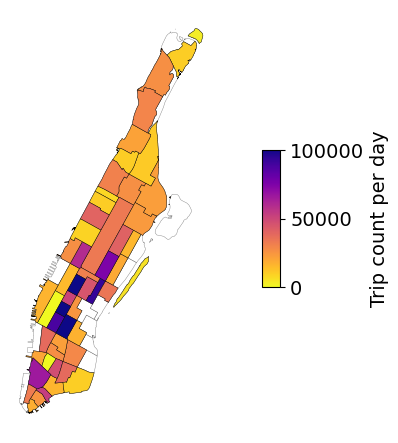

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rc('mathtext', fontset = 'cm')
plt.rcParams['font.size'] = 14

nyc = gpd.read_file('../NYC_zones/taxi_zones.shp')
manh = nyc.loc[nyc['LocationID'].isin(manhattan)]
manh['LocationID'] = manh['LocationID'].astype(int)
df_count = pd.DataFrame()
df_count['LocationID'] = manhattan

fig, ax = plt.subplots(1, 1, figsize=(3.7, 5.5))
var = np.sum(mat[manhattan - 1, :], axis = 1) / 366
pos = np.where(var == 0)
var[pos[0]] = np.nan

manh.plot(ax = ax, color='white', edgecolor='black', linewidth = 0.3, alpha = 0.5)

df_count['count'] = var
gdf_count = manh.set_index('LocationID').join(df_count.set_index('LocationID')).reset_index()
gdf_count.plot('count', cmap = 'plasma_r', edgecolor = 'black', linewidth = 0.3,
               vmin = 0, vmax = 1e+5, ax = ax, legend = False) # plasma_r, coolwarm

ax.set_axis_off()
cbar_ax = fig.add_axes([0.92, 0.375, 0.05, 0.25])
sm = plt.cm.ScalarMappable(cmap = 'plasma_r', norm = plt.Normalize(vmin = 0, vmax = 1e+5))
sm._A = []
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Trip count per day')
plt.show()
# fig.savefig('Manhattan_subway_trips.png', bbox_inches = 'tight')

## Sparse Autoregression

### 2D Case

In [3]:
import numpy as np
from docplex.mp.model import Model

def ts_pair(x, d):
    T = x.shape[0]
    x_tilde = x[d : T]
    A = np.zeros((T - d, d))
    for k in range(d):
        A[:, k] = x[d - k - 1 : T - k - 1]
    return x_tilde, A

def data2para(mat, d):
    N = mat.shape[0]
    C = np.zeros((d, d))
    F = np.zeros(d)
    for n in range(N):
        x_tilde, A = ts_pair(mat[n, :], d)
        C += A.T @ A
        F += A.T @ x_tilde
    return C, F

def sparse_ar_mip(C, F, tau):
    model = Model(name = 'Sparse Autoregression')
    d = F.shape[0]
    w = [model.continuous_var(lb = 0, name = f'w_{k}') for k in range(d)]
    beta = [model.binary_var(name = f'beta_{k}') for k in range(d)]
    model.minimize(model.sum(w[k] * model.sum(w[t] * C[k, t] for t in range(d)) 
                             - 2 * w[k] * F[k] for k in range(d)))
    model.add_constraint(model.sum(beta[k] for k in range(d)) <= tau)
    model.add_constraint(model.sum(w[k] for k in range(d)) == 1)
    for k in range(d):
        model.add_constraint(w[k] <= beta[k])
    solution = model.solve()
    if solution:
        print(solution.get_values(w))
        w_coef = np.array(solution.get_values(w))
        ind = np.where(w_coef > 0)[0].tolist()
        print('Support set: ', ind)
        print('Coefficients w: ', w_coef[ind])
        print('Cardinality of support set: ', len(ind))
        return w_coef, ind
    else:
        print('No solution found.')
        return None

In [4]:
import numpy as np
from scipy.optimize import nnls

def sparse_ar_local(x, d, ind):
    T = x.shape[0]
    A = np.zeros((T - d, len(ind)))
    for k in range(len(ind)):
        A[:, k] = x[d - ind[k] - 1 : T - ind[k] - 1]
    w = np.zeros(d)
    w[ind], _ = nnls(A, x[d : T])
    return w

In [5]:
import time
import numpy as np

manhattan = np.array([127, 128, 153, 120, 243, 244, 116, 42, 152, 166, 41, 74, 194, 24, 151,
                      238, 75, 239, 43, 236, 263, 143, 142, 262, 50, 237, 141, 140, 202, 163,
                      48, 230, 161, 162, 229, 246, 100, 68, 186, 233, 164, 170, 90, 234, 137,
                      158, 249, 107, 113, 224, 114, 125, 79, 211, 4, 144, 231, 148, 232, 13,
                      261, 45, 209, 87, 12, 88]) # 105, 104, 103

year = 24
mat = np.load(f'NYC_subway_mob_{year:02d}.npz')['arr_0'][manhattan - 1, :]

N = mat.shape[0]
d = 24 * 7
C, F = data2para(mat, d)

tau = 6

start = time.time()
w, ind = sparse_ar_mip(C, F, tau)
W_tensor = np.zeros((N, d))
for n in range(N):
    W_tensor[n, :] = sparse_ar_local(mat[n, :], d, ind)
end = time.time()
print('Running time (s):', end - start)

[0.21430217593608888, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.03153166492261491, 0.14336070034878826, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.10784718910493653, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.06236367936127063, 0.4405945903263009]
Support set:  [0, 22, 23, 143, 166, 167]
Coefficients w:  [0.21430218 0.03153166 0.1433607  0.10784719 0.06236368 0.44059459]
Cardinality of support set:  6
Running time (s): 0.1249549388885498


/opt/anaconda3/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


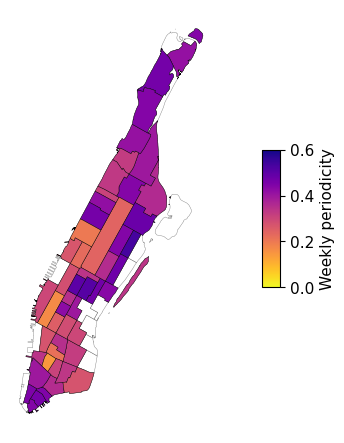

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rc('mathtext', fontset = 'cm')
plt.rcParams['font.size'] = 11

nyc = gpd.read_file('../NYC_zones/taxi_zones.shp')
manh = nyc.loc[nyc['LocationID'].isin(manhattan)]
manh['LocationID'] = manh['LocationID'].astype(int)
df_count = pd.DataFrame()
df_count['LocationID'] = manhattan

fig, ax = plt.subplots(1, 1, figsize=(3.7, 5.5))
pos = np.where(np.sum(mat, axis = 1) == 0)
W_tensor[pos[0], :] = np.nan
df_count['count'] = W_tensor[:, 167]
# df_count['count'] = W_tensor[:, 23]
manh.plot(ax = ax, color='white', edgecolor='black', linewidth = 0.3, alpha = 0.5)
gdf_count = manh.set_index('LocationID').join(df_count.set_index('LocationID')).reset_index()
gdf_count.plot('count', cmap = 'plasma_r', edgecolor = 'black', linewidth = 0.3,
               vmin = 0, vmax = 0.6, ax = ax, legend = False) # plasma_r, coolwarm
ax.set_axis_off()

cbar_ax = fig.add_axes([0.92, 0.375, 0.05, 0.25])
sm = plt.cm.ScalarMappable(cmap = 'plasma_r', norm = plt.Normalize(vmin = 0, vmax = 0.6))
sm._A = []
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Weekly periodicity')
plt.show()
# fig.savefig(f'manhattan_subway_{year:02d}.pdf', bbox_inches = 'tight')

### 3D Case

In [7]:
import numpy as np
from docplex.mp.model import Model

def ts_pair(x, d):
    T = x.shape[0]
    x_tilde = x[d : T]
    A = np.zeros((T - d, d))
    for k in range(d):
        A[:, k] = x[d - k - 1 : T - k - 1]
    return x_tilde, A

def data2para(data, d):
    N = len(data)
    M = data[0].shape[0]
    C = np.zeros((d, d))
    F = np.zeros(d)
    for m in range(M):
        for n in range(N):
            x_tilde, A = ts_pair(data[n][m, :], d)
            C += A.T @ A
            F += A.T @ x_tilde
    return C, F

def sparse_ar_mip(C, F, tau):
    model = Model(name = 'Sparse Autoregression')
    d = F.shape[0]
    w = [model.continuous_var(lb = 0, name = f'w_{k}') for k in range(d)]
    beta = [model.binary_var(name = f'beta_{k}') for k in range(d)]
    model.minimize(model.sum(w[k] * model.sum(w[t] * C[k, t] for t in range(d)) 
                             - 2 * w[k] * F[k] for k in range(d)))
    model.add_constraint(model.sum(beta[k] for k in range(d)) <= tau)
    model.add_constraint(model.sum(w[k] for k in range(d)) == 1)
    for k in range(d):
        model.add_constraint(w[k] <= beta[k])
    solution = model.solve()
    if solution:
        print(solution.get_values(w))
        w_coef = np.array(solution.get_values(w))
        ind = np.where(w_coef > 0)[0].tolist()
        print('Support set: ', ind)
        print('Coefficients w: ', w_coef[ind])
        print('Cardinality of support set: ', len(ind))
        return w_coef, ind
    else:
        print('No solution found.')
        return None

In [8]:
import numpy as np

data = []
for year in range(20, 25):
    mat = np.load(f'NYC_subway_mob_{year:02d}.npz')['arr_0'][manhattan - 1, :]
    data.append(mat)

In [9]:
import time

N = len(data)
M = data[0].shape[0]
d = 24 * 7
C, F = data2para(data, d)

tau = 6

start = time.time()
w, ind = sparse_ar_mip(C, F, tau)
W_tensor = np.zeros((M, N, d))
for m in range(M):
    for n in range(N):
        W_tensor[m, n, :] = sparse_ar_local(data[n][m, :], d, ind)
end = time.time()
print('Running time (s):', end - start)

[0.24105402118896374, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.03300468136480938, 0.13334430621632884, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.08943029405914324, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0811747308877613, 0.42199196628299346]
Support set:  [0, 22, 23, 143, 166, 167]
Coefficients w:  [0.24105402 0.03300468 0.13334431 0.08943029 0.08117473 0.42199197]
Cardinality of support set:  6
Running time (s): 0.1975419521331787
